In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt
import pandas as pd

### Linear Interpolation

Processing Delta Band...


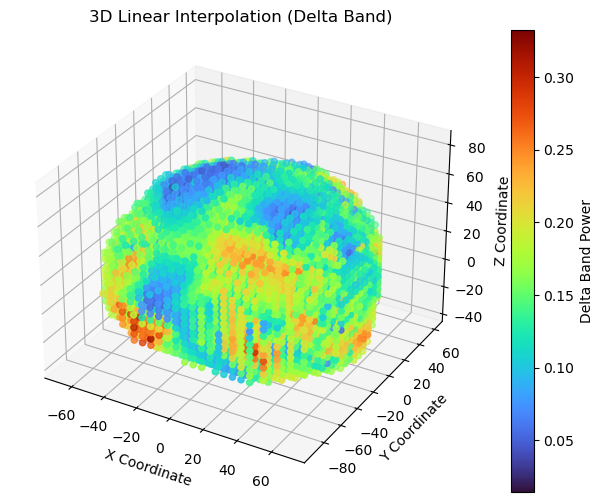

Processing Theta Band...


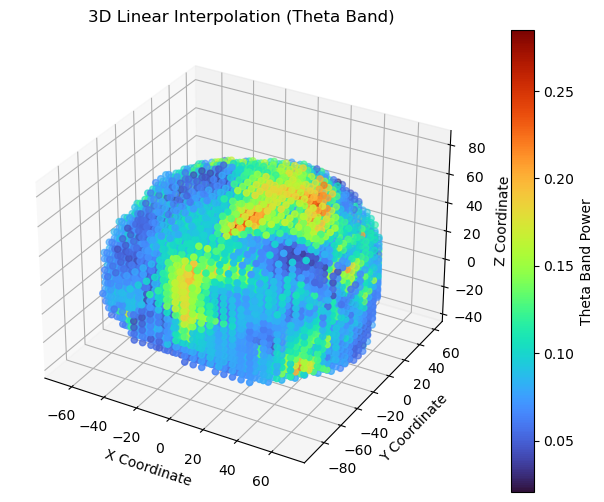

Processing Alpha Band...


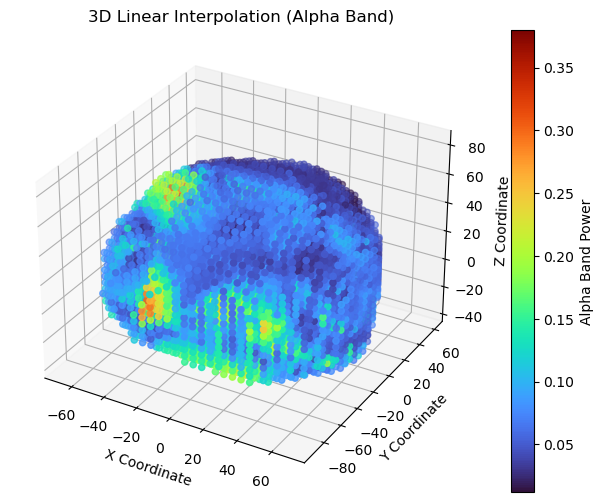

Processing Beta Band...


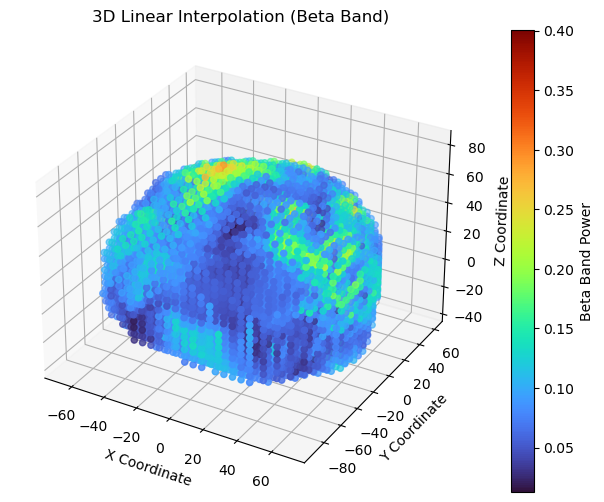

Processing Gamma Band...


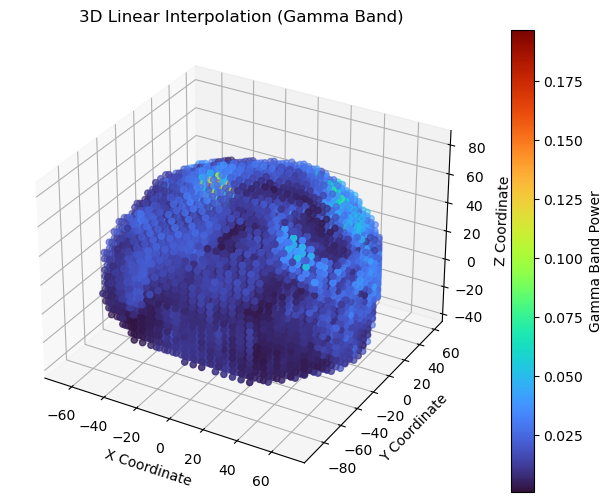


Interpolation Evaluation Metrics:
                MSE       MAE      RMSE        R²
Delta  4.474731e-06  0.000058  0.002115  0.999069
Theta  5.442982e-06  0.000058  0.002333  0.997733
Alpha  4.767241e-07  0.000023  0.000690  0.999799
Beta   2.425234e-06  0.000040  0.001557  0.999527
Gamma  8.679411e-07  0.000025  0.000932  0.997418


In [3]:
# Load the data
coords = np.load('coords.npy')  # Ensure the file is in the script's directory
band_powers = np.load('band_powers.npy', allow_pickle=True).item()


# Extract x, y, z coordinates
x, y, z = coords[:, 0], coords[:, 1], coords[:, 2]

# Define a grid for 3D interpolation
resolution = 30  # Define resolution for interpolation
grid_x, grid_y, grid_z = np.meshgrid(
    np.linspace(min(x), max(x), resolution),
    np.linspace(min(y), max(y), resolution),
    np.linspace(min(z), max(z), resolution)
)

# Prepare a dictionary to store evaluation metrics
evaluation_metrics = {}

# Iterate over each frequency band and perform 3D interpolation
for band, values in band_powers.items():
    print(f'Processing {band} Band...')

    # Perform 3D linear interpolation
    grid_values = griddata((x, y, z), values, (grid_x, grid_y, grid_z), method='linear')

    # Evaluate interpolation accuracy by comparing interpolated values at the original points
    interp_values_at_samples = griddata((x, y, z), values, (x, y, z), method='linear')

    mse = mean_squared_error(values, interp_values_at_samples)
    mae = mean_absolute_error(values, interp_values_at_samples)
    rmse = sqrt(mse)
    r2 = r2_score(values, interp_values_at_samples)

    evaluation_metrics[band] = {
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }

    # 3D Visualization of interpolated data
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(grid_x, grid_y, grid_z, c=grid_values.ravel(), cmap='turbo')
    ax.set_title(f'3D Linear Interpolation ({band} Band)')
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.set_zlabel('Z Coordinate')
    fig.colorbar(sc, label=f'{band} Band Power')
    plt.show()

# Display results
df_metrics = pd.DataFrame(evaluation_metrics).T
print("\nInterpolation Evaluation Metrics:")
print(df_metrics)


## KNN Interpolation

Processing Delta Band using 3D KNN Interpolation...


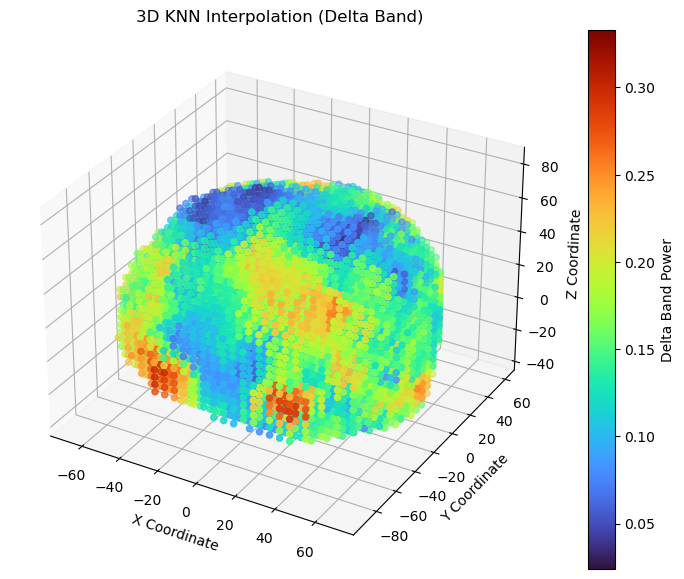

Processing Theta Band using 3D KNN Interpolation...


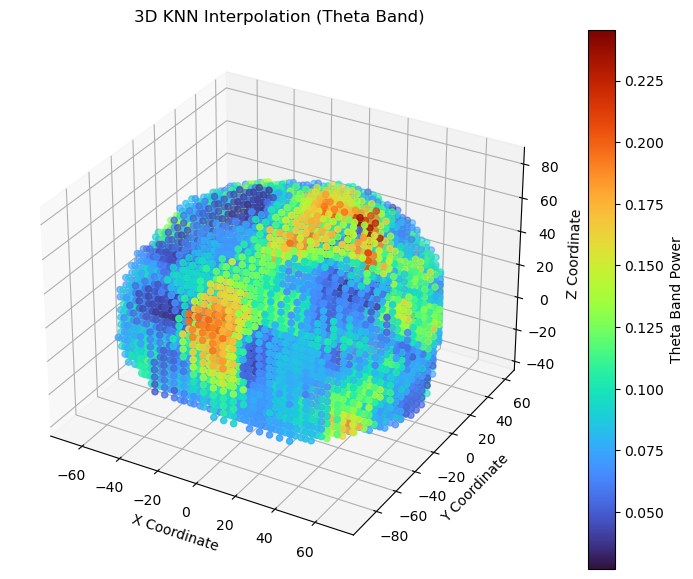

Processing Alpha Band using 3D KNN Interpolation...


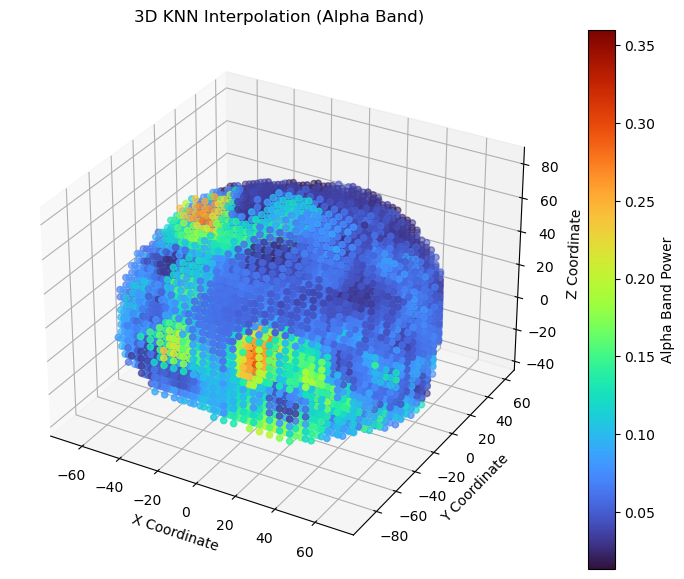

Processing Beta Band using 3D KNN Interpolation...


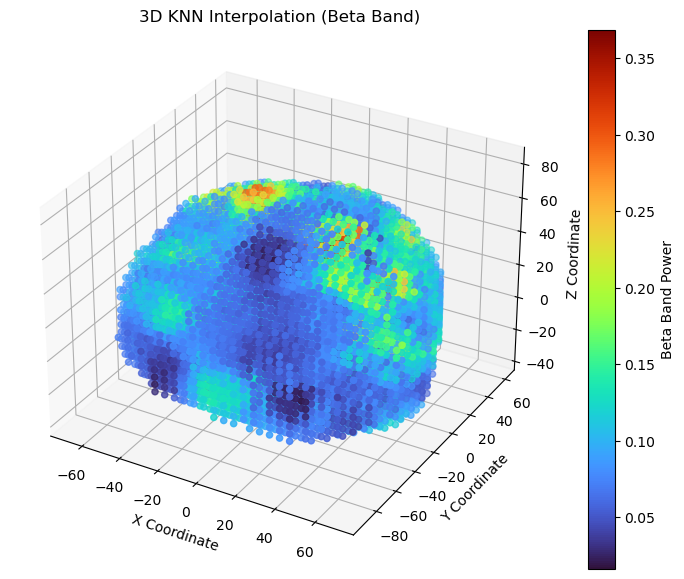

Processing Gamma Band using 3D KNN Interpolation...


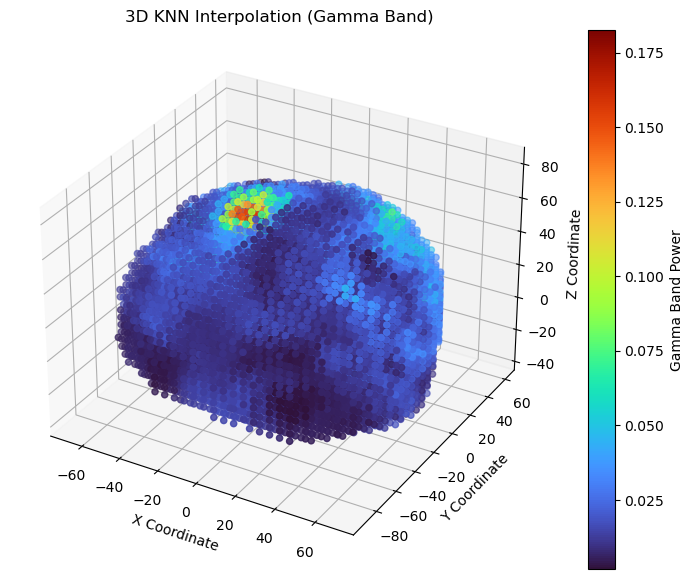


3D KNN Interpolation Evaluation Metrics:
                MSE       MAE      RMSE        R²
Delta  2.237366e-06  0.000058  0.001496  0.999535
Theta  2.721491e-06  0.000058  0.001650  0.998867
Alpha  2.383620e-07  0.000023  0.000488  0.999900
Beta   1.212617e-06  0.000040  0.001101  0.999764
Gamma  4.339705e-07  0.000025  0.000659  0.998709


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt
import pandas as pd
from scipy.spatial import ConvexHull, Delaunay

# Load the data
coords = np.load('coords.npy')
band_powers = np.load('band_powers.npy', allow_pickle=True).item()

# Extract x, y, z coordinates
x, y, z = coords[:, 0], coords[:, 1], coords[:, 2]
xyz_points = np.column_stack((x, y, z))

# Create a convex hull of the brain points to define the boundaries
hull = ConvexHull(xyz_points)
delaunay = Delaunay(xyz_points)

# Define a dense grid over the approximate region of the brain
resolution = 30
grid_x, grid_y, grid_z = np.meshgrid(
    np.linspace(min(x), max(x), resolution),
    np.linspace(min(y), max(y), resolution),
    np.linspace(min(z), max(z), resolution)
)

# Flatten the grid for KNN predictions
grid_points = np.column_stack((grid_x.ravel(), grid_y.ravel(), grid_z.ravel()))

# Mask out grid points that are outside the brain's convex hull
inside_hull = delaunay.find_simplex(grid_points) >= 0
valid_points = grid_points[inside_hull]

# Prepare dictionary for evaluation metrics
evaluation_metrics = {}

# Iterate over each frequency band and perform 3D KNN interpolation
for band, values in band_powers.items():
    print(f'Processing {band} Band using 3D KNN Interpolation...')

    # Initialize KNN Regressor (using 5 neighbors with distance weighting)
    knn = KNeighborsRegressor(n_neighbors=5, weights='distance')

    # Fit the KNN model to the band power data
    knn.fit(xyz_points, values)

    # Predict interpolated values for the valid brain points
    grid_values = knn.predict(valid_points)

    # Evaluate interpolation accuracy by comparing interpolated values at original sample points
    interp_values_at_samples = knn.predict(xyz_points)

    mse = mean_squared_error(values, interp_values_at_samples)
    mae = mean_absolute_error(values, interp_values_at_samples)
    rmse = sqrt(mse)
    r2 = r2_score(values, interp_values_at_samples)

    evaluation_metrics[band] = {
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }

    # 3D Visualization of interpolated data (within brain shape)
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Scatter plot of interpolated valid points (brain-shaped)
    sc = ax.scatter(
        valid_points[:, 0], valid_points[:, 1], valid_points[:, 2],
        c=grid_values, cmap='turbo', s=20
    )
    
    ax.set_title(f'3D KNN Interpolation ({band} Band)')
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.set_zlabel('Z Coordinate')

    fig.colorbar(sc, label=f'{band} Band Power')
    plt.show()

# Display Results
df_metrics = pd.DataFrame(evaluation_metrics).T
print("\n3D KNN Interpolation Evaluation Metrics:")
print(df_metrics)


## Splining Interpolation

 - Fitting a smooth curve between the known points 
 - Instead of using a straight line this uses piecewise polynomial functions

Processing Delta Band using 3D Spline Interpolation...


/Users/inayahkhan/Library/jupyterlab-desktop/jlab_server/lib/python3.8/site-packages/scipy/interpolate/_rbf.py:267: LinAlgWarning: Ill-conditioned matrix (rcond=3.28679e-39): result may not be accurate.
  self.nodes = linalg.solve(self.A, self.di)


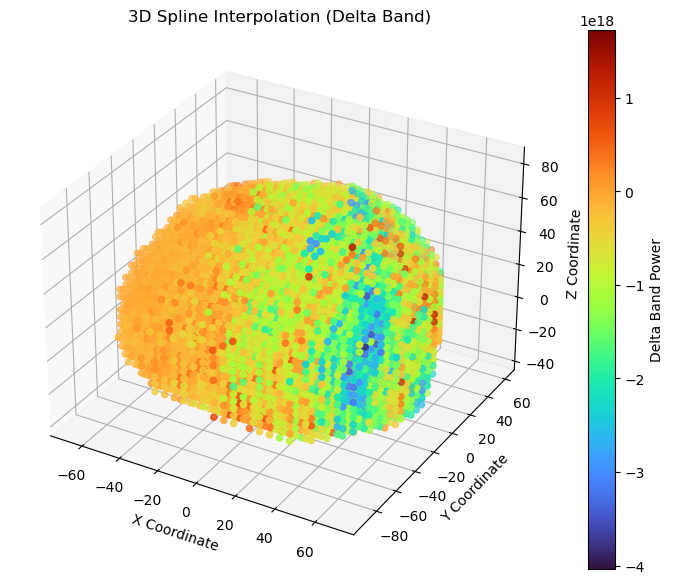

Processing Theta Band using 3D Spline Interpolation...


/Users/inayahkhan/Library/jupyterlab-desktop/jlab_server/lib/python3.8/site-packages/scipy/interpolate/_rbf.py:267: LinAlgWarning: Ill-conditioned matrix (rcond=3.28679e-39): result may not be accurate.
  self.nodes = linalg.solve(self.A, self.di)


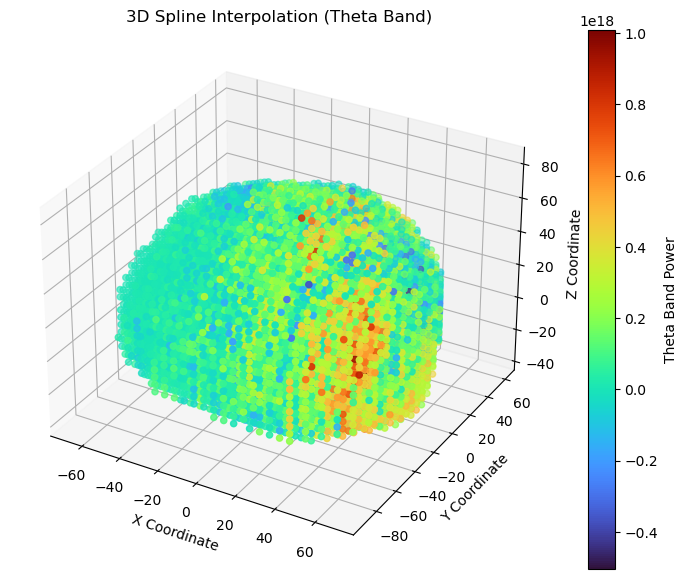

Processing Alpha Band using 3D Spline Interpolation...


/Users/inayahkhan/Library/jupyterlab-desktop/jlab_server/lib/python3.8/site-packages/scipy/interpolate/_rbf.py:267: LinAlgWarning: Ill-conditioned matrix (rcond=3.28679e-39): result may not be accurate.
  self.nodes = linalg.solve(self.A, self.di)


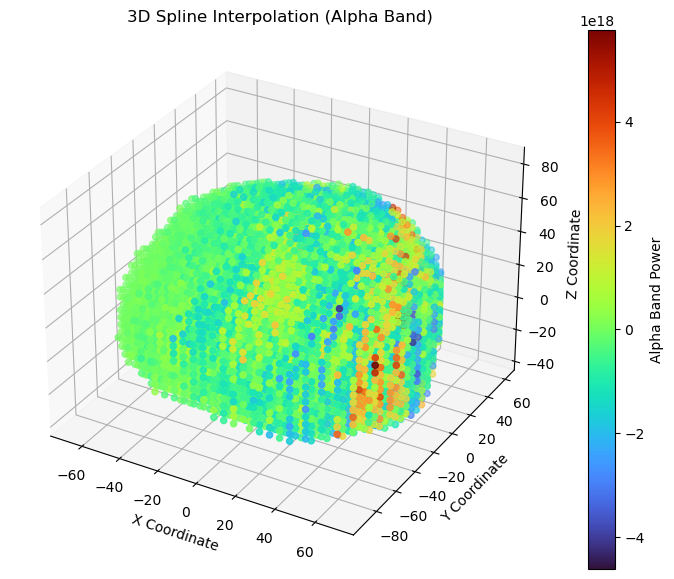

Processing Beta Band using 3D Spline Interpolation...


/Users/inayahkhan/Library/jupyterlab-desktop/jlab_server/lib/python3.8/site-packages/scipy/interpolate/_rbf.py:267: LinAlgWarning: Ill-conditioned matrix (rcond=3.28679e-39): result may not be accurate.
  self.nodes = linalg.solve(self.A, self.di)


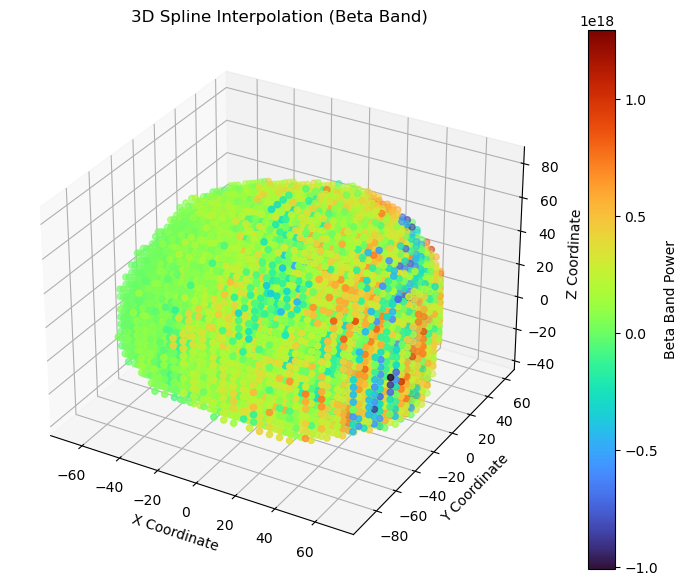

Processing Gamma Band using 3D Spline Interpolation...


/Users/inayahkhan/Library/jupyterlab-desktop/jlab_server/lib/python3.8/site-packages/scipy/interpolate/_rbf.py:267: LinAlgWarning: Ill-conditioned matrix (rcond=3.28679e-39): result may not be accurate.
  self.nodes = linalg.solve(self.A, self.di)


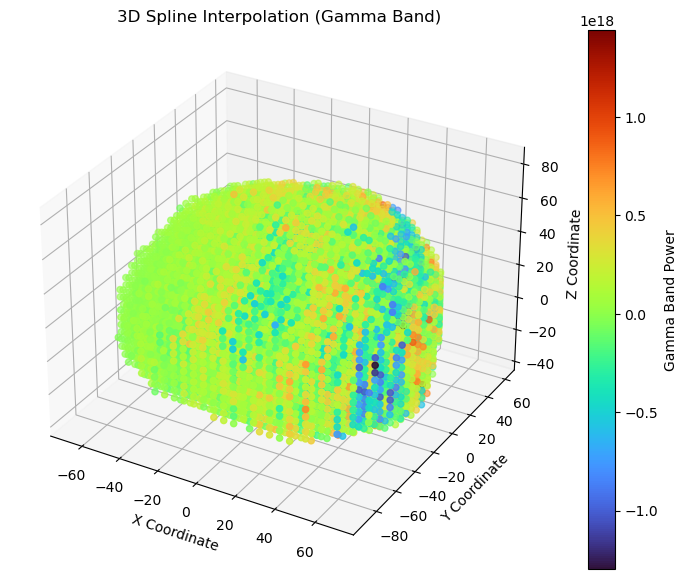


3D Spline Interpolation Evaluation Metrics:
                MSE           MAE          RMSE            R²
Delta  7.431833e+35  5.553288e+17  8.620808e+17 -1.545858e+38
Theta  3.275958e+34  1.119178e+17  1.809961e+17 -1.364401e+37
Alpha  7.827427e+35  5.583178e+17  8.847275e+17 -3.295842e+38
Beta   6.609612e+34  1.692163e+17  2.570917e+17 -1.289031e+37
Gamma  4.856574e+34  1.373270e+17  2.203764e+17 -1.444583e+38


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import Rbf, griddata
from scipy.spatial import ConvexHull, Delaunay
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt
import pandas as pd

# Load the data
coords = np.load('coords.npy')  
band_powers = np.load('band_powers.npy', allow_pickle=True).item()

# Extract x, y, z coordinates
x, y, z = coords[:, 0], coords[:, 1], coords[:, 2]
xyz_points = np.column_stack((x, y, z)) 

# Define a grid for interpolation
resolution = 30
grid_x, grid_y, grid_z = np.meshgrid(
    np.linspace(min(x), max(x), resolution),
    np.linspace(min(y), max(y), resolution),
    np.linspace(min(z), max(z), resolution)
)

# Flatten the grid into points
grid_points = np.column_stack((grid_x.ravel(), grid_y.ravel(), grid_z.ravel()))

# Step 1: Compute the convex hull of the original points
hull = ConvexHull(xyz_points)
hull_delaunay = Delaunay(xyz_points)

# Step 2: Mask out points outside the convex hull
inside_hull = hull_delaunay.find_simplex(grid_points) >= 0
valid_grid_points = grid_points[inside_hull]

# Prepare dictionary for evaluation metrics
evaluation_metrics = {}

# Step 3: Perform Interpolation Inside the Hull
for band, values in band_powers.items():
    print(f'Processing {band} Band using 3D Spline Interpolation...')

    # Convert values to numpy array
    values = np.array(values)

    # RBF-based spline interpolation (only within the valid hull points)
    interpolator = Rbf(x, y, z, values, function='cubic')

    # Predict interpolated values only at valid points
    grid_values = interpolator(valid_grid_points[:, 0],
                               valid_grid_points[:, 1],
                               valid_grid_points[:, 2])

    # Evaluate interpolation accuracy
    interp_values_at_samples = interpolator(x, y, z)

    mse = mean_squared_error(values, interp_values_at_samples)
    mae = mean_absolute_error(values, interp_values_at_samples)
    rmse = sqrt(mse)
    r2 = r2_score(values, interp_values_at_samples)

    # Store metrics
    evaluation_metrics[band] = {
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }

    # 3D Visualisation (only valid points within the hull)
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    sc = ax.scatter(
        valid_grid_points[:, 0], valid_grid_points[:, 1], valid_grid_points[:, 2],
        c=grid_values, cmap='turbo', s=20
    )

    ax.set_title(f'3D Spline Interpolation ({band} Band)')
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.set_zlabel('Z Coordinate')

    fig.colorbar(sc, label=f'{band} Band Power')
    plt.show()

# Display Results
df_metrics = pd.DataFrame(evaluation_metrics).T
print("\n3D Spline Interpolation Evaluation Metrics:")
print(df_metrics)


Processing Delta Band using 3D Spline Interpolation...


/Users/inayahkhan/Library/jupyterlab-desktop/jlab_server/lib/python3.8/site-packages/scipy/interpolate/_rbf.py:267: LinAlgWarning: Ill-conditioned matrix (rcond=2.51559e-33): result may not be accurate.
  self.nodes = linalg.solve(self.A, self.di)


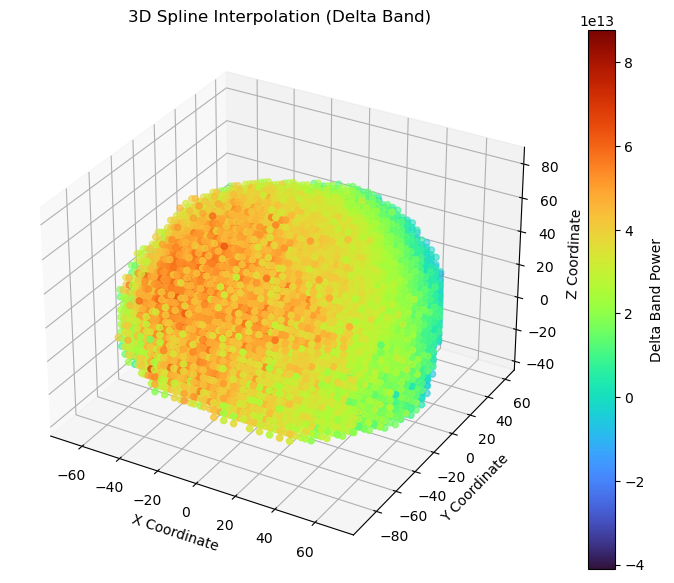

Processing Theta Band using 3D Spline Interpolation...


/Users/inayahkhan/Library/jupyterlab-desktop/jlab_server/lib/python3.8/site-packages/scipy/interpolate/_rbf.py:267: LinAlgWarning: Ill-conditioned matrix (rcond=2.51559e-33): result may not be accurate.
  self.nodes = linalg.solve(self.A, self.di)


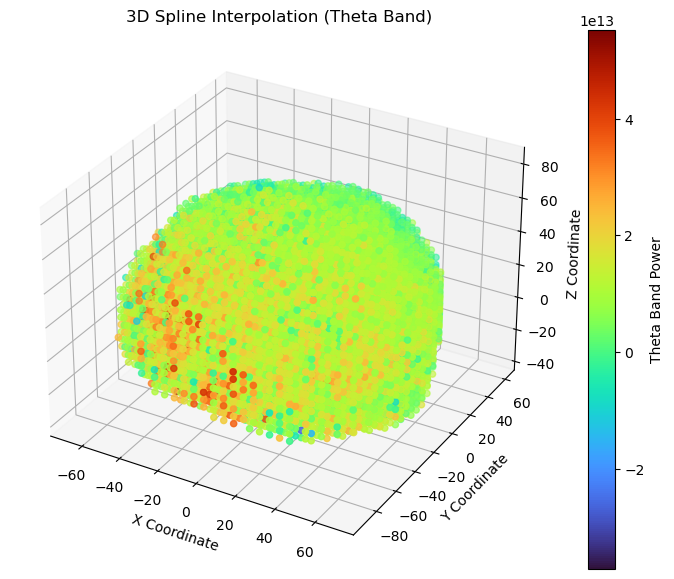

Processing Alpha Band using 3D Spline Interpolation...


/Users/inayahkhan/Library/jupyterlab-desktop/jlab_server/lib/python3.8/site-packages/scipy/interpolate/_rbf.py:267: LinAlgWarning: Ill-conditioned matrix (rcond=2.51559e-33): result may not be accurate.
  self.nodes = linalg.solve(self.A, self.di)


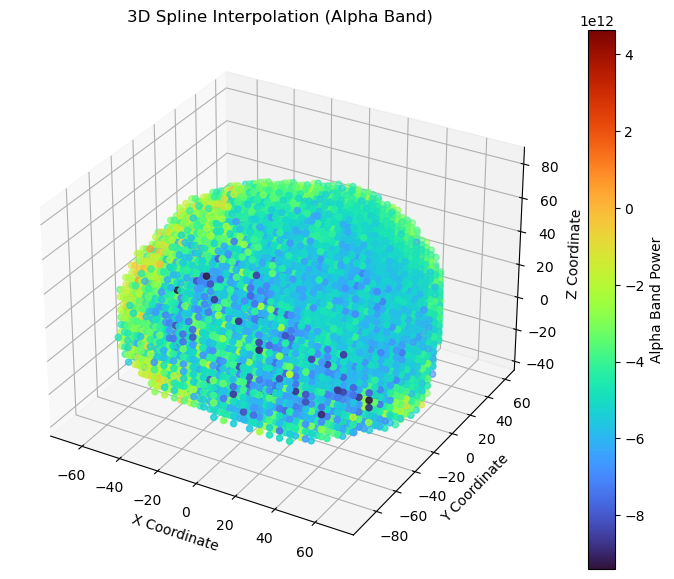

Processing Beta Band using 3D Spline Interpolation...


/Users/inayahkhan/Library/jupyterlab-desktop/jlab_server/lib/python3.8/site-packages/scipy/interpolate/_rbf.py:267: LinAlgWarning: Ill-conditioned matrix (rcond=2.51559e-33): result may not be accurate.
  self.nodes = linalg.solve(self.A, self.di)


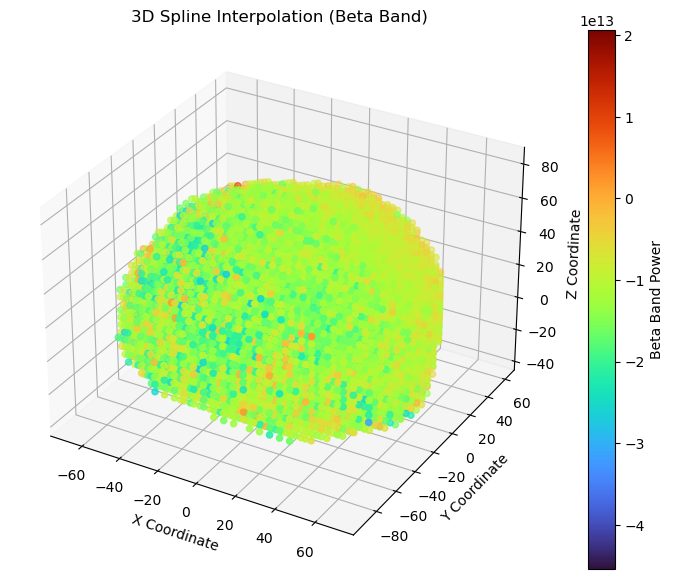

Processing Gamma Band using 3D Spline Interpolation...


/Users/inayahkhan/Library/jupyterlab-desktop/jlab_server/lib/python3.8/site-packages/scipy/interpolate/_rbf.py:267: LinAlgWarning: Ill-conditioned matrix (rcond=2.51559e-33): result may not be accurate.
  self.nodes = linalg.solve(self.A, self.di)


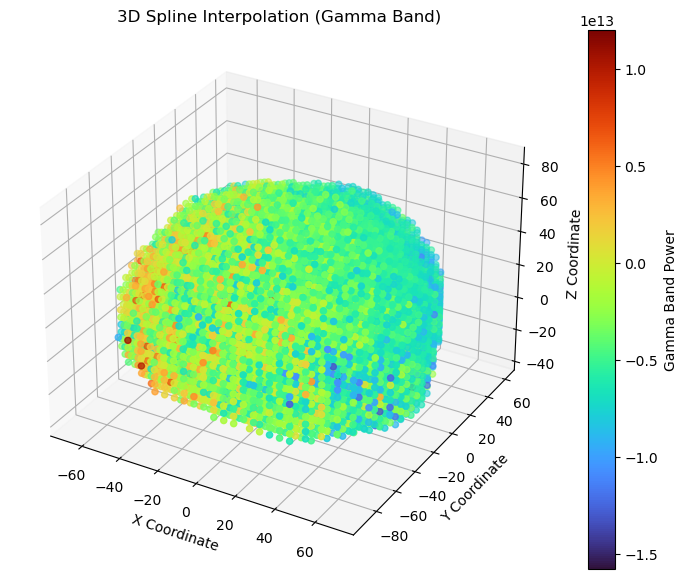


3D Spline Interpolation Evaluation Metrics:
                MSE           MAE          RMSE            R²
Delta  1.004465e+27  2.618389e+13  3.169329e+13 -2.089336e+29
Theta  1.360170e+26  9.494041e+12  1.166263e+13 -5.664960e+28
Alpha  1.638893e+25  3.685264e+12  4.048324e+12 -6.900774e+27
Beta   1.572142e+26  1.098720e+13  1.253851e+13 -3.066051e+28
Gamma  2.677753e+25  4.483501e+12  5.174701e+12 -7.964952e+28


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import Rbf, griddata
from scipy.spatial import ConvexHull, Delaunay
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt
import pandas as pd

# Load the data
coords = np.load('coords.npy')  
band_powers = np.load('band_powers.npy', allow_pickle=True).item()

# Extract x, y, z coordinates
x, y, z = coords[:, 0], coords[:, 1], coords[:, 2]
xyz_points = np.column_stack((x, y, z)) 

# Define a grid for interpolation
resolution = 30
grid_x, grid_y, grid_z = np.meshgrid(
    np.linspace(min(x), max(x), resolution),
    np.linspace(min(y), max(y), resolution),
    np.linspace(min(z), max(z), resolution)
)

# Flatten the grid into points
grid_points = np.column_stack((grid_x.ravel(), grid_y.ravel(), grid_z.ravel()))

# Step 1: Compute the convex hull of the original points
hull = ConvexHull(xyz_points)
hull_delaunay = Delaunay(xyz_points)

# Step 2: Mask out points outside the convex hull
inside_hull = hull_delaunay.find_simplex(grid_points) >= 0
valid_grid_points = grid_points[inside_hull]

# Prepare dictionary for evaluation metrics
evaluation_metrics = {}

# Step 3: Perform Interpolation Inside the Hull
for band, values in band_powers.items():
    print(f'Processing {band} Band using 3D Spline Interpolation...')

    # Convert values to numpy array
    values = np.array(values)

    # RBF-based spline interpolation (only within the valid hull points)
    interpolator = Rbf(x, y, z, values, function='linear')

    # Predict interpolated values only at valid points
    grid_values = interpolator(valid_grid_points[:, 0],
                               valid_grid_points[:, 1],
                               valid_grid_points[:, 2])

    # Evaluate interpolation accuracy
    interp_values_at_samples = interpolator(x, y, z)

    mse = mean_squared_error(values, interp_values_at_samples)
    mae = mean_absolute_error(values, interp_values_at_samples)
    rmse = sqrt(mse)
    r2 = r2_score(values, interp_values_at_samples)

    # Store metrics
    evaluation_metrics[band] = {
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }

    # 3D Visualisation (only valid points within the hull)
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    sc = ax.scatter(
        valid_grid_points[:, 0], valid_grid_points[:, 1], valid_grid_points[:, 2],
        c=grid_values, cmap='turbo', s=20
    )

    ax.set_title(f'3D Spline Interpolation ({band} Band)')
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.set_zlabel('Z Coordinate')

    fig.colorbar(sc, label=f'{band} Band Power')
    plt.show()

# Display Results
df_metrics = pd.DataFrame(evaluation_metrics).T
print("\n3D Spline Interpolation Evaluation Metrics:")
print(df_metrics)
